실험03. 변압기의 특성실험



60Hz 입력전압일 때 1차측 입력 전압값(오실로스코프에서 실효치) 측정한 값을 입력(ex: 10V인 경우 10을 입력):     10
2차측 전압을 측정하여 rms 전압값(실효치)을 입력(ex: 20V인 경우 20을 입력):     20
1차측 입력 전류값(멀티미터로 AC 전류치) 측정한 값을 입력(ex: 50mA인 경우 0.05를 입력):     0.05
2차측 출력 전류값(오실로스코프 measure 기능으로 읽은 RL=1k[ohm]에 걸리는 전압값에서 자동 계산) 측정한 값을 입력(ex: 20V인 경우 20mA이므로 0.02를 입력):     0.02



        [표 3-1]
 v1[V]        |  v2[V]         |  i1[A]         |  i2[A]         |  P1[W]       |  P2[W]       
----------------------------------------------------------------------------------------------
 10.0         |  20.0          |  0.05          |  0.02          |  0.5         |  0.4         


 1차측과 전력과 2차측 전력의 비로 효율을 계산하면, 효율(Efficiency) :  80.0 [%]




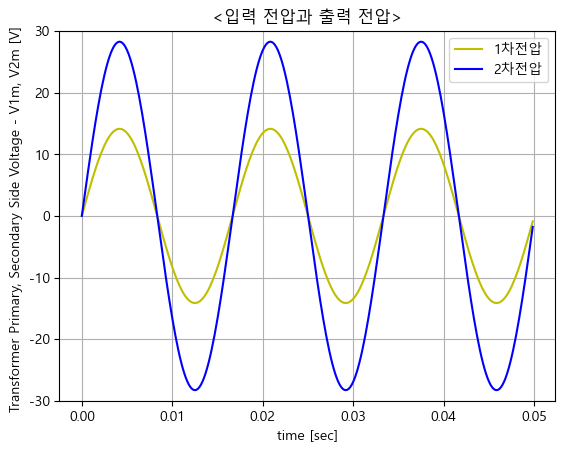

In [29]:
import numpy as np
import math

# 실험 제목 출력 
print("실험03. 변압기의 특성실험")
print()

# 실험에 사용한 회로 정수를 입력함
f=60       # 주파수 입력 
n=2        # 1차와 2차 턴수비 (여기서는 1:2 이므로 2)
RL=1e3     # 부하저항으로 실험에 사용한 R값   1k[ohm]

# 실험결과 측정치를 입력함
V1m=input("60Hz 입력전압일 때 1차측 입력 전압값(오실로스코프에서 실효치) 측정한 값을 입력(ex: 10V인 경우 10을 입력):    ")     # 측정해서 입력하세요.
V1m=float(V1m)    #입력한 값은 일단 문자임, 따라서 문자에서 실수로 변경.

V2m=input("2차측 전압을 측정하여 rms 전압값(실효치)을 입력(ex: 20V인 경우 20을 입력):    ")    # 측정해서 입력하세요.
V2m=float(V2m)  #입력한 값은 일단 문자임, 따라서 문자에서 실수로 변경.

I1m=input("1차측 입력 전류값(멀티미터로 AC 전류치) 측정한 값을 입력(ex: 50mA인 경우 0.05를 입력):    ")     # 측정해서 입력하세요.
I1m=float(I1m)    #입력한 값은 일단 문자임, 따라서 문자에서 실수로 변경.

I2m=input("2차측 출력 전류값(오실로스코프 measure 기능으로 읽은 RL=1k[ohm]에 걸리는 전압값에서 자동 계산) 측정한 값을 입력(ex: 20V인 경우 20mA이므로 0.02를 입력):    ")     # 측정해서 입력하세요.
I2m=float(I2m)    #입력한 값은 일단 문자임, 따라서 문자에서 실수로 변경.


P1=V1m * I1m   # 1차측 입력 전력을 계산 
P2=V2m * I2m   # 2차측 출력 전력을 계산

Efficiency = P2/P1 * 100

print()
print("        [표 3-1]")
# 데이터 헤더 및 데이터 출력
print(" {:<12} |  {:<12}  |  {:<12}  |  {:<12}  |  {:<12}|  {:<12}".format("v1[V]","v2[V]","i1[A]","i2[A]","P1[W]","P2[W]"))
print("----------------------------------------------------------------------------------------------")
print(" {:<12} |  {:<12}  |  {:<12}  |  {:<12}  |  {:<12}|  {:<12}".format(V1m, V2m, I1m, I2m, round(P1,3), round(P2,3)))
print()
print()
print(" 1차측과 전력과 2차측 전력의 비로 효율을 계산하면, 효율(Efficiency) : ", Efficiency, "[%]")
print()
print()


# 오실로스코프 화면 파형 그리기
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

f=60
fs=f*100;   dt=1/fs;  N=300   #샘플링주파수=표시주파수*100Hz, 300개 샘플이면 3주기 표시함 
t=np.arange(0,N)*dt           # 시간축은 1주기*300샘플
y1t=(math.sqrt(2))*V1m*np.sin(2*np.pi*f*t)   # 1차측 전압: 크기 √￣2*V1m, 주파수 60Hz 정현파
y2t=(math.sqrt(2))*V2m*np.sin(2*np.pi*f*t)   # 2차측 전압: 크기 √￣2*V2m, 주파수 60Hz 정현파
plt.xlabel("time [sec]")
plt.ylabel("Transformer Primary, Secondary Side Voltage - V1m, V2m [V] ")
plt.title("<입력 전압과 출력 전압>")
plt.plot(t, y1t,"y", label="1차전압")
plt.plot(t, y2t,"b", label="2차전압")
plt.legend(loc="upper right")
plt.ylim(-30,30)
plt.grid()
plt.show()

